# Review / problems session

## A simple problem: local extrema of $\frac{sin x}{x}$ on $(-n \pi, n\pi)$

### Math background:
* **Critical points**: We say that $x_0$ is a critical point of a function $f$ if and only of $f'(x_0) = 0$ or $f$ is not diferentiable at $x_0$.
* **First derivative rule**: If a function $f$ is differentiable on an interval $(a,b)$ and admits a local extremum $x_0$ in $(a,b)$, then $f'(x_0) = 0$.
* **Second derivative rule**: If $f$ is twice differentiable in an interval containing $x_0$ and $f'(x_0) = 0$:
    * If $f''(x_0) > 0$ then $x_0$ is a *local minimizer* for $f$.
    * If $f''(x_0) < 0$ then $x_0$ is a *local maximizer* for $f$.
    * If $f''(x_0) = 0$, the test is inconclusive.
* **Mean value theorem**: If a function $f$ is continuous on a closed interval $[a,b]$ and differentiable on $(a,b)$, then there exists $c \in [a,b]$ such that $f'(c) = \frac{f(b) - f(a)}{b-a}$.
* **Corollary**: under the same asumptions, of $f(a) = f(b) = 0$, there exists at least one $c \in [a,b]$ such that $f'(c) = 0$.

#### Warning: 
numpy and sympy have different definitions of `sinc`: numpy uses $\frac{sin \pi x}{\pi x}$ while sympy uses the more common $\frac{\sin x}{x}$.


In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import scipy
%matplotlib widget

In [2]:
def f(x):
    return np.sinc(x / np.pi)

x = sp.Symbol('x')
ff = sp.sinc(x)

Text(0.5, 1.0, 'Extrema of the cardinal sine')

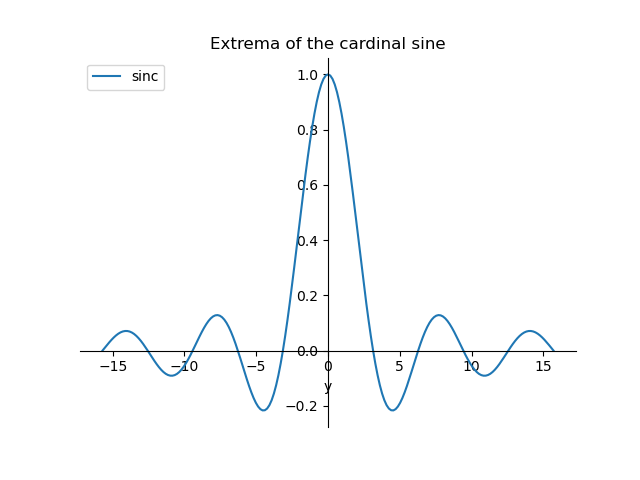

In [3]:
### Let's plot f with numpy / matplotlib
plt.close('all')
n = 5
fig, ax = plt.subplots()
X = np.linspace(-n*np.pi, n*np.pi, 201)
ax.plot(X,f(X), label = 'sinc')
ax.spines[['left', 'bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left')
ax.set_xlabel('x')
ax.set_xlabel('y')
ax.set_title('Extrema of the cardinal sine')

We know that $\frac{sin x}{x}$ vanishes at any $x = k\pi$ $k \in \mathbb{Z} \setminus \{0\}$ (remember $\lim_{x \to 0} \frac{sin x}{x} = 1$). 
Let's add these points:

In [4]:
roots = [k*np.pi for k in range(-5,6) if k != 0]
ax.scatter(roots, [0]*len(roots), label = 'roots', zorder = 10)

We can now search extrema between roots using `scipy.optimize.root_scalar`. First, we compute $f'$ using sympy, then make it a python function using `lambdify`

In [5]:
ffprime = sp.simplify(sp.diff(ff,x))
fprime = sp.lambdify(x, ffprime)
ffprime

(x*cos(x) - sin(x))/x**2

In [6]:
ext = []
for i in range(len(roots)-1):
    a = roots[i]
    b = roots[i+1]
    sol = scipy.optimize.root_scalar(fprime, method = 'bisect', bracket = (a,b))#, x1 = b)
    if sol.converged:
        ext.append(sol.root)
        print(f'Extremum at {sol.root}')
    else:
        print(f'Could not find extremum in ({a},{b}), {sol}')
print(ext)

Extremum at -14.06619391283256
Extremum at -10.904121659428089
Extremum at -7.725251836937442
Extremum at -4.493409457910044
Could not find extremum in (-3.141592653589793,3.141592653589793),       converged: False
           flag: The function value at x=0.0 is NaN; solver cannot continue.
 function_calls: 3
     iterations: nan
           root: 0.0
         method: bisect
Extremum at 4.493409457910043
Extremum at 7.725251836937441
Extremum at 10.904121659428089
Extremum at 14.06619391283256
[-14.06619391283256, -10.904121659428089, -7.725251836937442, -4.493409457910044, 4.493409457910043, 7.725251836937441, 10.904121659428089, 14.06619391283256]


<lambdifygenerated-1>:2: RuntimeWarning: invalid value encountered in scalar divide
  return (x*cos(x) - sin(x))/x**2


Let's use the second derivative test to check if the extrema are local min or max of $f$

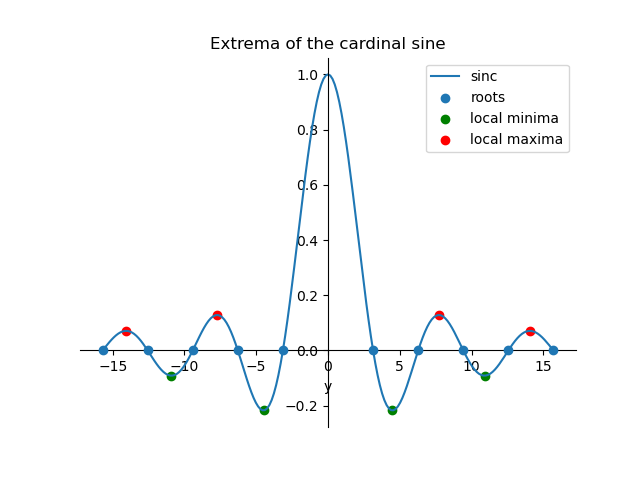

In [7]:
ffpprime = sp.simplify(sp.diff(ff,x,2))
localmin = []
localmax = []
undef = []
for x0 in ext:
    ffpp = ffpprime.subs(x,x0).evalf()
    if ffpp < 0:
        localmax.append(x0)
    elif ffpprime.subs(x,x0).evalf() > 0:
        localmin.append(x0)
    else:
        undef.append(x0)

ax.scatter(localmin, [f(x0) for x0 in localmin], color = 'green', label = 'local minima')
ax.scatter(localmax, [f(x0) for x0 in localmax], color = 'red', label = 'local maxima')
ax.legend()
fig.show()

In [9]:
import sympy as sp

x = sp.Symbol('x')
f = sp.Function('f')(x)

diffeq = sp.Eq(lhs = sp.diff(f,x,2), rhs = -1)
a = 0
b = 0

sol = sp.dsolve(diffeq, f, ics = {f.subs(x,0) : 0, f.subs(x,1) : 0})
sol

Eq(f(x), -x**2/2 + x/2)

## A boundary value problem
A classical problem consists in finding a function $u$ satisfying
$$
\begin{cases}
-u''(x) = f & \text{ in } (0,1),\\
u(0) = a,  & \\
u(1) = b,
\end{cases}
$$
where $a, b$ are two given numbers and $f$ is a given function. This problem appear in fluid and solid mechanics, in heat transfer, data analysis, and many other fields.

We are goint to try to approximate solutions of this problem using python in two different ways by approximating the values of the folution function $u$ at $N$ equidistributed points in $(0,1)$, which we will represent by a numpy array `U`.

### Explicit finite difference:
The solution array can be approximated through the following iterative algorithm:
Let $dx = 1/(N-1)$ and $0 < dt < dx^2/2$. 
* Initialize `U` such that `U_0 = a` and `U_{N-1} = b`
* Iterate until convergence
     - Compute $dU$ such that $dU_i = -(U_{i-1} - 2dU_i + dU_{i+1}) / dx^2 - F_i$, $i = 1 \dots N-2$.
     - Compute $U \leftarrow U - dt dU$



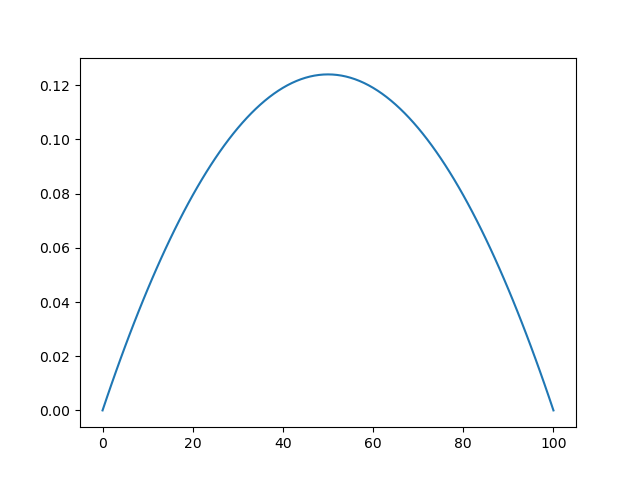

In [10]:
# number of points
N = 101
# u function yet to be known
u = np.zeros(N)
# we will take f(x) to be f(x) = 1 for now
f = np.ones(N)
dx = 1/(N-1)
# stepsize
dt = dx**2/2 * 0.99

niter = 10000
du = np.zeros(N)
for i in range(niter):
    for i in range(1,N-1):
        du[i] = -(u[i-1] - 2*u[i] +u[i+1]) / dx**2 - f[i]
    u -= dt * du

plt.close('all')
fig, ax = plt.subplots()
ax.plot(u)

### Implicit finite differences:
`U` can also be computed directly as the solution of the linear system `KU = F`, where $K$ is a $N\times N$ matrix such that 
$$K[i,j] = \begin{cases}
\frac{-1}{dx^2} & \text{ if } 0 < i < N-1 \text{ and } j = i-1,\\
\frac{2}{dx^2} & \text{ if } 0 < i < N-1 \text{ and } j = i,\\
\frac{-1}{dx^2} & \text{ if } 0 < i < N-1 \text{ and } j = i+1,\\
1 & \text{ if } i = 0 \text{ and } j = 0,\\
1 & \text{ if } i = N-1 \text{ and } j = N-1,\\
0 & \text{ otherwise.}
\end{cases}
$$
and $F$ is a vector of length $N$ such that
$$
F_i = \begin{cases}
a & \text{ if } i = 0,\\
b & \text{ if } i = N-1,\\
f(i/(N-1)) & \text{ otherwise.}\\
\end{cases}
$$


In [11]:
K = np.zeros((N,N))
F = np.ones(N)
K[0,0] = 1
K[N-1,N-1] = 1
F[0] = 0
F[N-1] = 0
for i in range(1,N-1):
    K[i,i-1] = -1. / dx**2
    K[i,i]   = 2. / dx**2
    K[i,i+1] = -1. / dx**2

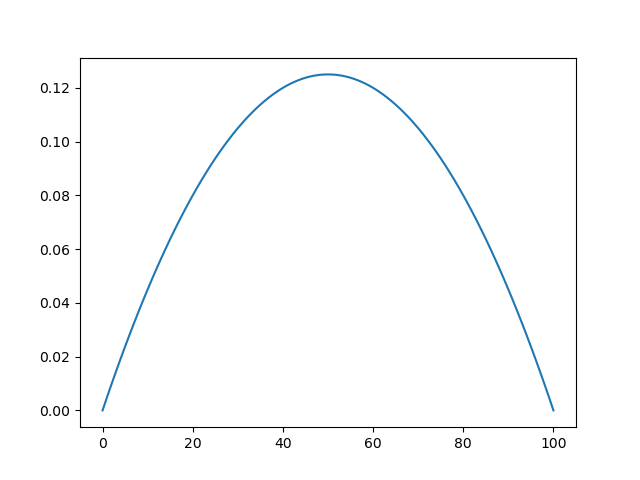

In [ ]:
U = np.linalg.solve(K,F)
plt.close('all')
fig, ax = plt.subplots()
ax.plot(U)